# TASK 3: NATURAL LANGUAGE PROCESSING (NLP)- SENITMEMT ANALYSIS

In [1]:
import pandas as pd

# load your specific dataset
df = pd.read_csv('3) Sentiment dataset.csv')

#Display the first 5 rows in a clean table format
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Download the neccessary NLTK data files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')





[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [3]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# set up our lemmatizer and English stopwords list
lemmatizer =  WordNetLemmatizer()
stop_words = set( stopwords.words('english'))

def preprocess_text(text):
    """Clean text by lowecasing, removing punctuations, tokenizing, and lemmatizing."""
    # convert text ro lowercase
    text = str(text).lower()
    # Remove punctuation and special charactersusing a regular expression
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize ( split into individual words
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Jion words back into single string
    return ' '.join(cleaned_tokens)

# Apply function to create a new column in our dataframe
df['cleaned_Text'] = df['Text'].apply(preprocess_text)

#Display original text next to our new cleaned text to notice difference
print(df[['Text','cleaned_Text']].head())
    

                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   

                       cleaned_Text  
0       enjoying beautiful day park  
1          traffic terrible morning  
2          finished amazing workout  
3  excited upcoming weekend getaway  
4  trying new recipe dinner tonight  


In [4]:
# make sure to install Textblob
!pip install textblob

In [5]:
from  textblob  import TextBlob
def get_sentiment(text):
    """
    Analyse the text and assigns a sentiment category based on the polarity score
    """
    # create a TextBlob object
    analysis = TextBlob(str(text))

    # Extract the polarity score
    polarity = analysis.sentiment.polarity

    # classify the score
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
# Apply function to create our final sentiment column
df['Predicted_Sentiment'] = df['cleaned_Text'].apply(get_sentiment)

# print out the final counts for each category to see our results
print("--- Sentiment Distribution ---")
print(df['Predicted_Sentiment'].value_counts())



--- Sentiment Distribution ---
Predicted_Sentiment
Neutral     348
Positive    277
Negative    107
Name: count, dtype: int64


In [6]:
#check the first row to see if the original text, cleaned text and the final prediction side by side 
print("\n--- Final Data Preview ---")
print(df[['Text','cleaned_Text','Predicted_Sentiment']].head())


--- Final Data Preview ---
                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   

                       cleaned_Text Predicted_Sentiment  
0       enjoying beautiful day park            Positive  
1          traffic terrible morning            Negative  
2          finished amazing workout            Positive  
3  excited upcoming weekend getaway            Positive  
4  trying new recipe dinner tonight            Positive  


In [7]:
# to install matplotlib for visuals
!pip install wordcloud matplotlib

NameError: name 'wordcloud' is not defined

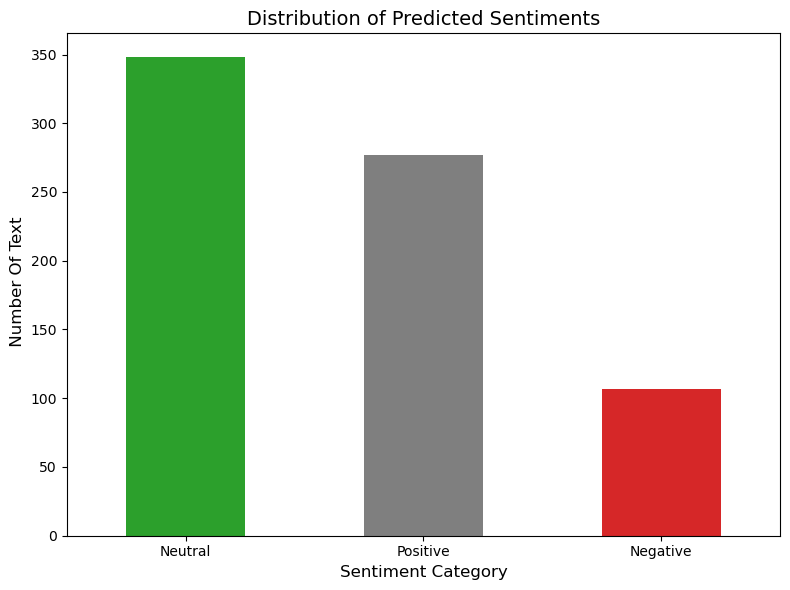

In [8]:
import matplotlib.pyplot as plt

# VISUALIZATIION 1:SENTIMENT DISTRIBUTION BAR CHART
# set up a figure for Bar Chart
plt.figure(figsize=(8,6))

#count how many texts fall into each category
sentiment_counts = df['Predicted_Sentiment'].value_counts()

#plot the barchart )
sentiment_counts.plot(kind='bar', color=['#2ca02c', '#7f7f7f', '#d62728'])
plt.title('Distribution of Predicted Sentiments', fontsize=14)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel(' Number Of Text', fontsize=12)
plt.tick_params(axis='x', rotation=0)      # this keeps the label horizintal

plt.tight_layout() # this ensures everthing fits nicely without overlapping
plt.show(wordcloud) # Displays the final image!


                         

In [ ]:
# VISUALIZATION 2: WORD CLOUD FOR WORD FREQUENCY
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# set up a figure for wordcloud
plt.figure(figsize=(10,6))

# combine all cleaned text from every row into one giant string
all_text_combined = ' '.join(df['cleaned_Text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                       background_color='white',
                       colormap='viridis',
                       max_words=100).generate(all_text_combined )

# plot and display the wordcloud 
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # this hides the grid and the axes lines for a cleaner look
plt.title('Most Frequent Words in Dataset', fontsize=14)

plt.tight_layout() 
plt.show(wordcloud)

# PUTTING BOTH VISUALS IN ONE SINGLE CELL

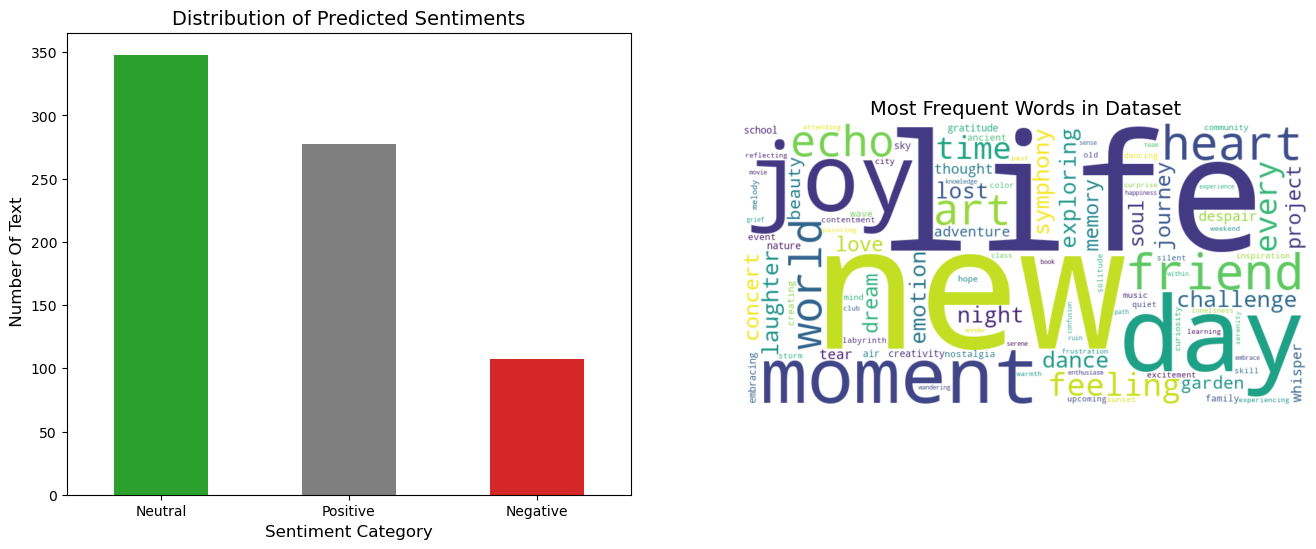

<Figure size 800x600 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# set up a figure with two subplots side by side( 1 row, 2 columns)
fig, axes = plt.subplots(1,2, figsize = (16, 6))
plt.figure(figsize=(8,6))
# VISUALIZATIION 1:SENTIMENT DISTRIBUTION BAR CHART
#count how many texts fall into each category
sentiment_counts = df['Predicted_Sentiment'].value_counts()

#plot the barchart on first subplot (axes[0])
sentiment_counts.plot(kind='bar', color=['#2ca02c', '#7f7f7f', '#d62728'], ax=axes[0])
axes[0].set_title('Distribution of Predicted Sentiments', fontsize=14)
axes[0].set_xlabel('Sentiment Category', fontsize=12)
axes[0].set_ylabel(' Number Of Text', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)      # this keeps the label horizintal

# VISUALIZATION 2: WORD CLOUD FOR WORD FREQUENCY

# combine all cleaned text from every row into one giant string
all_text_combined = ' '.join(df['cleaned_Text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                       background_color='white',
                       colormap='viridis',
                       max_words=100).generate(all_text_combined )

# plot the wordcloude on the second subplot(axes[1])
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off') # this hides the grid and the axes lines for a cleaner look
axes[1].set_title('Most Frequent Words in Dataset', fontsize=14)

plt.tight_layout() # this ensures everthing fits nicely without overlapping
plt.show(wordcloud) # Displays the final image!

# TASK 1: PREDICTIVE MODELING

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")
train_df = pd.read_csv('churn-bigml-80.csv')
test_df = pd.read_csv('churn-bigml-20.csv')

# Separate Features (X) and Target (y)
X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn'].astype(int) 

X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn'].astype(int)

# ==========================================
# 2. PREPROCESSING
# ==========================================
print("Preprocessing data...")
# One-Hot Encoding for categorical text columns
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns to ensure training and testing match exactly
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Feature Scaling for numerical columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# ==========================================
# 3. TRAIN & EVALUATE MODELS
# ==========================================
print("\nModel Evaluation Results:\n" + "="*25)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Evaluate
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

# ==========================================
# 4. HYPERPARAMETER TUNING (Grid Search)
# ==========================================
print("Starting Grid Search for Random Forest... (This might take a moment)\n")
param_grid = {
    'n_estimators': [50, 100], 
    'max_depth': [None, 10],    
    'min_samples_split': [2, 5]     
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, 
                           scoring='f1', 
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)
best_rf_model = grid_search.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test_scaled)

print("--- Optimized Random Forest Performance ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimized):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimized):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_optimized):.4f}")

Loading data...
Preprocessing data...

Model Evaluation Results:
--- Logistic Regression ---
Accuracy:  0.8591
Precision: 0.5106
Recall:    0.2526
F1-Score:  0.3380

--- Decision Tree ---
Accuracy:  0.9340
Precision: 0.7802
Recall:    0.7474
F1-Score:  0.7634

--- Random Forest ---
Accuracy:  0.9430
Precision: 0.9831
Recall:    0.6105
F1-Score:  0.7532

Starting Grid Search for Random Forest... (This might take a moment)

--- Optimized Random Forest Performance ---
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy:  0.9445
Precision: 0.9677
Recall:    0.6316
F1-Score:  0.7643
